# Day-to-day evolution of (ridepooling) supply and demand
Module for simulating ridesourcing evolution, including pooled rides

Contribution by Arjan de Ruijter - a.j.f.deruijter@tudelft.nl

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys # add MaaSSim and MaaSSim/MaaSSim to path (not needed if already in path)
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from MaaSSim.utils import save_config, get_config, load_G, generate_demand, initialize_df, empty_series, \
    slice_space, test_space, read_requests_csv
from MaaSSim.maassim import Simulator
from MaaSSim.data_structures import structures as inData
from MaaSSim.d2d_sim import *
from MaaSSim.d2d_demand import *
from MaaSSim.d2d_supply import *
from MaaSSim.d2d_shared import prep_shared_rides
from MaaSSim.decisions import dummy_False
from MaaSSim.exmas import main

In [3]:
import pandas as pd
import zipfile
import logging
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
import random
# import ExMAS
plt.style.use('ggplot')
np.random.seed(0)
random.seed(0)

In [4]:
# Load config
params = get_config('../../data/config/delft.json')  # load configuration
params.paths.albatross = '../../data/albatross'

In [5]:
# Experiment replications and number of threads to be used
params.parallel.nReplications = 1
params.parallel.nThread = 1

# Main experimental settings
params.nP = 500 # travellers
params.nV = 50 # drivers
params.nD = 10 # days
params.simTime = 2 # hours

In [6]:
# Other day-to-day settings
params.evol.drivers.kappa = 0.2 # learning weight (supply-side)
params.evol.drivers.res_wage.mean = 25 #euros/h
params.evol.drivers.gini = 0.35 # gini coefficient used to establish sigma parameter of log-norm distribution of res wage
params.evol.drivers.init_inc_ratio = 1 #expected income of informed drivers at start of sim as ratio of res wage

params.evol.drivers.inform.prob_start = 1 # probability of being informed at start of sim
params.evol.drivers.inform.beta = 0.1 # information transmission rate
params.evol.drivers.inform.std_fact = 0.5 # multiplier of the standard deviation of experienced income used in signal

params.evol.drivers.regist.prob_start = 1 # probability of being registered if informed at start of sim
params.evol.drivers.regist.beta = 0.2 # registration choice model parameter
params.evol.drivers.regist.cost_comp = 20 # daily share of registration costs (euros)
params.evol.drivers.regist.samp = 0.5 # probability of making (de)regist decision
params.evol.drivers.regist.min_work_exp = 0 # Working experience required before deregistration is possible
params.evol.drivers.regist.min_days = 5 # Minimum number of registered days before driver can deregister

params.evol.drivers.particip.beta = 0.1 # participation choice model parameter
params.evol.drivers.particip.probabilistic = True # stochasticity in participation choice

params.evol.travellers.inform.prob_start = 1 # probability that traveller is informed at start of sim
params.evol.travellers.inform.beta = 0.1 # information transmission rate (demand-side)
params.evol.travellers.inform.start_wait = 0 # expected waiting time at start of simulation
params.evol.travellers.inform.std_fact = 0.5 # multiplier of the standard deviation of experienced waiting time used in signal
params.evol.travellers.reject_penalty = 30 * 60 # seconds
params.evol.travellers.kappa = 0.2 # learning weight (demand-side)
params.evol.travellers.min_prob = 0.05 # filtering criterion, when probability is lower when waiting time is zero, never consider RS

params.evol.travellers.mode_pref.mean_vot = 10 # Mean VoT in euro/h
params.evol.travellers.mode_pref.access_multip = 2 # Multiplier of access time compared to in-vehicle time
params.evol.travellers.mode_pref.wait_multip = 2.5 # Multiplier of waiting time compared to in-vehicle time
params.evol.travellers.mode_pref.bike_multip = 2 # Multiplier of biking time compared to in-vehicle time
params.evol.travellers.mode_pref.beta_cost = -0.1592 # util/euro
params.evol.travellers.mode_pref.transfer_pen = 5 * 60 # seconds, to be added to IVT for each transfer
params.evol.travellers.mode_pref.ASC_car = 0 # util, rel to bike
params.evol.travellers.mode_pref.ASC_rs = 0
params.evol.travellers.mode_pref.ASC_pt =  0
params.evol.travellers.mode_pref.ASC_car_sd = 0 # standard deviation in ASCs
params.evol.travellers.mode_pref.ASC_rs_sd = 0
params.evol.travellers.mode_pref.ASC_pt_sd = 0
params.evol.travellers.mode_pref.ASC_bike_sd = 0
params.evol.travellers.mode_pref.gini = params.evol.drivers.gini

# Financial settings
params.platforms.base_fare = 1 #euro
params.platforms.fare = 1 #euro/km
params.platforms.min_fare = 0 # euro
params.platforms.comm_rate = 0.05 #rate
params.drivers.fuel_costs = 0.25 #euro/km

# Properties alternative modes
params.alt_modes.pt.option = False
params.alt_modes.pt.base_fare = 0.99 # euro
params.alt_modes.pt.km_fare = 0.174 # euro/km
params.alt_modes.car.km_cost = 0.5 # euro/km
params.alt_modes.car.diff_parking = True # different parking tariffs in city
params.alt_modes.car.park_cost = 7.5 # euro
params.alt_modes.car.park_cost_center = 15 # euro
params.alt_modes.car.access_time = 10 * 60 # s
params.speeds.bike = (1/2.5) * params.speeds.ride # m/s

# Regulation
params.platforms.reg_cap = np.inf # registration cap
params.platforms.ptcp_cap = np.inf # daily participation cap

# Demand settings
# params.demand_structure.origins_dispertion = -0.0003
# params.demand_structure.destinations_dispertion = -0.0003
params.dist_threshold_min = 2000 # min dist
# params.dist_threshold = 100000 # max dist

# Start time
# params.t0 = pd.Timestamp.now()
params.t0 = pd.Timestamp(2021, 11, 1, 9)

In [7]:
# Pooling settings
params.shareability.offered = True
params.shareability.min_discount = 0.3 # fraction of solo fare
params.shareability.add_discount = 0.3 # fraction of solo fare
params.shareability.shared_discount = 0.35 # as considered by platform in determ. of feasible rides (fraction of solo fare)
params.shareability.delay_value = 1
params.shareability.WtS_mean = 1.5 # Actual (mean) WtS multipl. in population
params.shareability.WtS = 1 # Willingness to share multipl. as considered by platform in determining feasible rides
params.shareability.WtS_std = 0 # St. dev. of WtS in population
params.shareability.matching_obj = 'u_pax' #minimize VHT for vehicles
params.shareability.pax_delay = 0 # additional delay for picking up travs
params.shareability.max_delay = 10 * 60 # max. allowed delay in pooled rides (sec.)
params.shareability.horizon = 600
params.shareability.max_degree = 2
params.shareability.share = 1
params.shareability.without_matching = True

In [8]:
# Compute (other) input parameters in ExMAS
params.shareability.avg_speed = params.speeds.ride
params.shareability.price = params.platforms.fare #eur/km
params.shareability.nP = params.nP
params.shareability.VoT = params.evol.travellers.mode_pref.mean_vot / 3600 # convert eur/h to eur/s

In [9]:
inData = load_G(inData, params, stats=True, set_t=False)  # download graph for the 'params.city' and calc the skim matrices
if params.alt_modes.car.diff_parking:
    inData = diff_parking(inData) # determine which nodes are in center

In [10]:
inData = generate_demand(inData, params, avg_speed = True)

In [11]:
# Load processed Albatross file, the OTP result, and compute PT fares
# inData = load_albatross_proc(inData, params, avg_speed = True)
# inData.requests = inData.requests.drop(['orig_geo', 'dest_geo', 'origin_y', 'origin_x', 'destination_y', 'destination_x', 'time'], axis = 1)
# inData.pt_itinerary = load_OTP_result(params)
# inData = consist_OTP_alba(inData, params)

In [12]:
# Prepare supply and demand attributes
inData.passengers = prefs_travs(inData, params)
all_pax = mode_filter(inData, params)
inData.passengers = all_pax[all_pax.mode_choice == "day-to-day"]
inData.requests = inData.requests[inData.requests.pax_id.isin(inData.passengers.index)]
if params.alt_modes.pt.option:
    inData.pt_itinerary = inData.pt_itinerary[inData.pt_itinerary.pax_id.isin(inData.passengers.index)]
    inData.passengers.reset_index(drop=True, inplace=True)
    inData.requests.reset_index(drop=True, inplace=True)
    inData.pt_itinerary.reset_index(drop=True, inplace=True)
inData.requests['pax_id'] = inData.requests.index
inData.pt_itinerary['pax_id'] = inData.pt_itinerary.index
inData.passengers['informed'] = np.random.rand(len(inData.passengers)) < params.evol.travellers.inform.prob_start
inData.passengers['expected_wait'] = params.evol.travellers.inform.start_wait
inData.passengers['expected_wait_pool'] = params.evol.travellers.inform.start_wait
inData.passengers['expected_pool_disc'] = params.shareability.min_discount
inData.passengers['expected_pool_detour'] = 0
fixed_supply = generate_vehicles_d2d(inData, params)
inData.vehicles = fixed_supply.copy()
inData.vehicles.platform = inData.vehicles.apply(lambda x: 0, axis = 1)
inData.passengers.platforms = inData.passengers.apply(lambda x: [0], axis = 1)
inData.requests['platform'] = inData.requests.apply(lambda row: inData.passengers.loc[row.name].platforms[0], axis = 1) 
inData.platforms = pd.concat([inData.platforms,pd.DataFrame(columns=['base_fare','comm_rate','min_fare'])])
inData.platforms = initialize_df(inData.platforms)
inData.platforms.loc[0]=[params.platforms.fare,'Uber',30,params.platforms.base_fare,params.platforms.comm_rate,params.platforms.min_fare,]

In [13]:
inData = main(inData, params.shareability, plot=False) # create shareability graph (ExMAS) 

06-04-23 10:45:43-INFO-Initializing pairwise trip shareability between 500 and 500 trips.
06-04-23 10:45:43-INFO-creating combinations
06-04-23 10:45:44-INFO-249500	 nR*(nR-1)
06-04-23 10:46:03-INFO-Reduction of feasible pairs by 97.90%
06-04-23 10:46:03-INFO-Degree 2 	Completed


In [14]:
# Day-to-day simulation (incl. processing)
sim = Simulator(inData, params=params,
                    kpi_veh = D2D_veh_exp,
                    kpi_pax = d2d_kpi_pax,
                    f_driver_out = D2D_driver_out,
                    f_trav_out = d2d_no_request,
                    f_trav_mode = dummy_False,
                    logger_level=logging.WARNING)  # initialize

evol_micro = init_d2d_dotmap(params)
for day in range(params.get('nD', 1)):  # run iterations
    inData.passengers = mode_preday(inData, params)
    temp_rides = inData.sblts.rides.copy()
    temp_reqs = inData.sblts.requests.copy()
    
    rs_users = inData.passengers[(inData.passengers.mode_day == 'rs') | (inData.passengers.mode_day == 'pool')].index.tolist()
    poolers = inData.passengers[inData.passengers.mode_day == 'pool'].index.tolist()
    inData.sblts.rides = inData.sblts.rides[inData.sblts.rides.apply(lambda x: all(i in rs_users for i in x.indexes), axis=1)] # filter out all travellers opting for mode outside ride-hailing market
    inData.sblts.rides = inData.sblts.rides[inData.sblts.rides.apply(lambda x: (all(i in poolers for i in x.indexes) or x.kind == 1), axis=1)]  # filter out pooled trips for individuals opting for private ride
    inData.sblts.requests = inData.sblts.requests[inData.sblts.requests.apply(lambda x: x.pax_id in rs_users, axis=1)]
    
    inData = prep_shared_rides(inData, params.shareability)  # prepare schedules
    sim.make_and_run(run_id=day)  # prepare and SIM
    sim.output()  # calc results
    sim.last_res = sim.res[day].copy()
    del sim.res[day]

    drivers_summary = update_d2d_drivers(sim=sim,params=params)
    travs_summary = update_d2d_travellers(sim=sim,params=params)
    
    exp_df = update_work_exp(inData, drivers_summary)
    inData.vehicles.work_exp = exp_df.work_exp
    inData.days_since_reg = exp_df.days_since_reg

    res_inf_driver = wom_driver(inData, params = params)
    inData.vehicles.informed = res_inf_driver
    inData.vehicles.expected_income = learning_unregist(inData, drivers_summary, params = params)
    
    res_regist = platform_regist(inData, drivers_summary, params = params)
    inData.vehicles.registered = res_regist.registered
    inData.vehicles.work_exp = res_regist.work_exp
    inData.vehicles.pos = fixed_supply.pos
    inData.vehicles.rejected_reg = res_regist.rejected_reg
    
    res_inf_trav = wom_trav(inData, travs_summary, params = params)
    inData.passengers.informed = res_inf_trav.informed
    inData.passengers.expected_wait = res_inf_trav.perc_wait
    inData.passengers.expected_pool_disc = res_inf_trav.perc_disc
    inData.passengers.expected_pool_detour = res_inf_trav.perc_detour
    
    inData.sblts.rides = temp_rides.copy()
    inData.sblts.requests = temp_reqs.copy()
    
    evol_micro = d2d_summary_day(evol_micro, drivers_summary, travs_summary, day)
    evol_micro = d2d_summ_pooling(evol_micro, travs_summary)

06-04-23 10:46:04-WARNING-Setting up 2h simulation at 2021-11-01 08:00:09 for 50 vehicles and 500 passengers in Delft, Netherlands
06-04-23 10:47:02-WARNING-day 0: simulation time 45.1 s
06-04-23 10:47:03-WARNING-assertion tests for simulation results - passed
06-04-23 10:47:56-WARNING-day 1: simulation time 42.0 s
06-04-23 10:47:57-WARNING-assertion tests for simulation results - passed
06-04-23 10:48:47-WARNING-day 2: simulation time 40.0 s
06-04-23 10:48:49-WARNING-assertion tests for simulation results - passed
06-04-23 10:49:32-WARNING-day 3: simulation time 35.2 s
06-04-23 10:49:34-WARNING-assertion tests for simulation results - passed
06-04-23 10:50:18-WARNING-day 4: simulation time 35.7 s
06-04-23 10:50:20-WARNING-assertion tests for simulation results - passed
06-04-23 10:51:05-WARNING-day 5: simulation time 37.3 s
06-04-23 10:51:07-WARNING-assertion tests for simulation results - passed
06-04-23 10:51:48-WARNING-day 6: simulation time 33.6 s
06-04-23 10:51:50-WARNING-asserti

In [15]:
evol_micro, evol_agg = d2d_agg_statistics(evol_micro, params) # multi-day stats

In [16]:
# Save d2d stats to zip file
with zipfile.ZipFile('evol.zip', 'w') as csv_zip:
    csv_zip.writestr("evol_agg_supply.csv", evol_agg.supply.to_csv())
    csv_zip.writestr("evol_agg_demand.csv", evol_agg.demand.to_csv())

In [17]:
evol_agg.supply

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc
day,,,,,,,,,
0,50,50,0,28,0,50.539889,51.872048,50.539889,26.425607
1,50,50,0,21,0,47.689888,49.804478,47.689888,31.695595
2,50,50,0,26,0,46.168741,37.796308,46.168741,26.189538
3,50,50,0,16,0,44.961637,38.765043,44.961637,35.391469
4,50,50,0,18,0,44.745729,32.403179,44.745729,31.994528
5,50,50,0,22,0,44.716306,34.681516,44.716306,28.571318
6,50,50,0,21,0,44.178608,33.607695,44.178608,26.343976
7,50,50,0,25,0,43.568456,32.942181,43.568456,24.113480
8,50,50,0,18,0,42.685586,34.297308,42.685586,30.834333


In [18]:
evol_agg.demand

,inform,requests,req_solo,req_pool,gets_offer_solo,gets_offer_pooling,act_shared,mean_wait_solo,corr_mean_wait_solo,mean_wait_pooling,...,perc_wait_solo,perc_wait_req,perc_wait_pool,mean_disc,perc_disc,mean_detour,perc_detour,bike,car,pt
day,,,,,,,,,,,,,,,,,,,,,
0,500,304,135,169,135,169,166,188.200658,188.200658,120.986842,...,0.000000,0.000000,0.000000,0.594675,0.300000,46.460526,0.000000,162,34,0
1,500,271,157,114,155,114,114,285.104089,296.284133,139.237918,...,26.863694,22.453875,16.380702,0.600000,0.319920,41.256506,5.649600,179,50,0
2,500,261,168,93,168,93,86,201.471264,201.471264,79.291188,...,57.516429,50.934713,39.045161,0.577419,0.333504,29.961686,10.088800,185,54,0
3,500,242,173,69,152,63,58,307.869767,474.347107,115.730233,...,72.945387,68.231504,56.412638,0.552174,0.343512,25.902326,13.214880,204,54,0
4,500,221,171,50,167,48,40,250.362791,292.434389,54.902326,...,105.644604,103.177897,94.741760,0.540000,0.350098,18.367442,15.609960,228,51,0
5,500,225,189,36,189,36,26,153.937778,153.937778,30.240000,...,111.467843,112.448860,117.599200,0.516667,0.354580,11.502222,17.273659,221,54,0
6,500,196,170,26,170,26,22,151.015306,151.015306,22.081633,...,114.712112,112.563629,98.515852,0.553846,0.357185,14.698980,18.308098,246,58,0
7,500,209,192,17,192,17,8,154.952153,154.952153,18.665072,...,127.732110,127.072452,119.622197,0.441176,0.359496,4.239234,19.465089,233,58,0
8,500,198,173,25,173,25,16,203.106061,203.106061,38.782828,...,114.516948,111.561172,91.107203,0.492000,0.360211,8.974747,19.807382,238,64,0


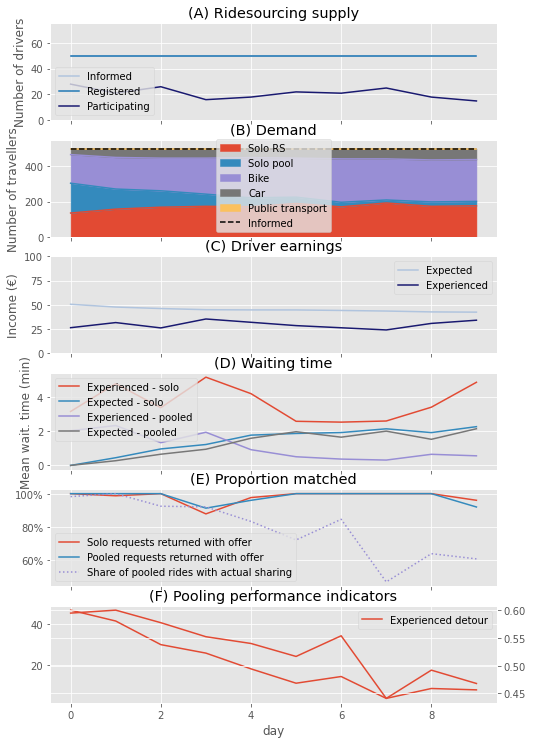

In [19]:
# Plot evolution of main performance indicators
fig, axes = plt.subplots(nrows=6, ncols=1, figsize = (8,12.5), sharex = True)
evol_agg.supply[['inform','regist','particip']].plot(ax = axes[0], color=['lightsteelblue','tab:blue','midnightblue'])
axes[0].set_title('(A) Ridesourcing supply')
axes[0].legend(['Informed','Registered','Participating'])
axes[0].set_ylim([0,params.nV + 25])
axes[0].set_ylabel('Number of drivers')
evol_agg.supply[['mean_perc_inc','mean_exp_inc']].plot(ax = axes[2], color=['lightsteelblue','midnightblue'])
axes[2].set_title('(C) Driver earnings')
axes[2].legend(['Expected','Experienced'])
axes[2].set_ylim([0,math.ceil(max(evol_agg.supply.mean_perc_inc.max(),evol_agg.supply.mean_exp_inc.max())/50)*50])
axes[2].set_ylabel('Income (\u20ac)')

evol_agg.demand[['req_solo','req_pool','bike','car','pt']].plot.area(ax = axes[1])
h,l = axes[1].get_legend_handles_labels()
evol_agg.demand['inform'].plot(ax = axes[1], color = 'black', linestyle = 'dashed', label = 'informed')
line = Line2D([0], [0],color='black', linestyle ='dashed')
axes[1].set_title('(B) Demand')
axes[1].set_ylim([0,len(inData.passengers) * 1.1])
axes[1].set_ylabel('Number of travellers')
h.extend([line])
axes[1].legend(labels=["Solo RS","Solo pool","Bike","Car","Public transport","Informed"], handles=h)

evol_agg.demand['mean_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Experienced - solo')
# evol_agg.demand['corr_mean_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Corrected exp. - solo')
evol_agg.demand['perc_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Expected - solo')
evol_agg.demand['mean_wait_pooling'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Experienced - pooled')
# evol_agg.demand['corr_mean_wait_pooling'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Corrected exp. - pooled')
evol_agg.demand['perc_wait_pool'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Expected - pooled')
axes[3].legend()
axes[3].set_title('(D) Waiting time')
axes[3].set_ylabel('Mean wait. time (min)')

evol_agg.demand['proport_match_solo'] = evol_agg.demand.gets_offer_solo / evol_agg.demand.req_solo * 100
evol_agg.demand['proport_match_pool'] = evol_agg.demand.gets_offer_pooling / evol_agg.demand.req_pool * 100
evol_agg.demand['act_shared_rel'] = evol_agg.demand.act_shared / evol_agg.demand.gets_offer_pooling * 100
evol_agg.demand['proport_match_solo'].plot(ax = axes[4], label='Solo requests returned with offer')
evol_agg.demand['proport_match_pool'].plot(ax = axes[4], label='Pooled requests returned with offer')
evol_agg.demand['act_shared_rel'].plot(ax = axes[4], label='Share of pooled rides with actual sharing', linestyle = 'dotted')
axes[4].legend()
axes[4].set_title('(E) Proportion matched')
axes[4].yaxis.set_major_formatter(mtick.PercentFormatter())

ax_sec = axes[5].twinx()
evol_agg.demand['mean_disc'].plot(ax = ax_sec, label='Experienced discount')
evol_agg.demand['mean_detour'].plot(ax = axes[5], label='Experienced detour')
axes[5].legend()
axes[5].set_title('(F) Pooling performance indicators')

plt.savefig('d2d-evo.png')

---

In [20]:
sim.last_res.veh_exp

,nRIDES,nREJECTED,DRIVING_TIME,DRIVING_DIST,REVENUE,COST,NET_INCOME,OUT,FORCED_OUT,STARTS_DAY,...,ARRIVES_AT_PICKUP,MEETS_TRAVELLER_AT_PICKUP,DEPARTS_FROM_PICKUP,ARRIVES_AT_DROPOFF,CONTINUES_SHIFT,STARTS_REPOSITIONING,REPOSITIONED,DECIDES_NOT_TO_DRIVE,ENDS_SHIFT,NOT_ALLOWED_TO_DRIVE
veh,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
2,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
3,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
4,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
5,13.0,0.0,6416.0,64.16,50.3500,16.0400,34.3100,False,False,0,...,0.0,390.0,4000.0,7087.0,0,0,0,0,0,0
6,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
7,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0
8,12.0,0.0,6193.0,61.93,48.4405,15.4825,32.9580,False,False,0,...,0.0,360.0,3899.0,7305.0,0,0,0,0,0,0
9,0.0,0.0,0.0,0.00,0.0000,0.0000,0.0000,True,False,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0


In [21]:
sim.last_res.pax_exp

,ACCEPTS_OFFER,ARRIVES_AT_DEST,ARRIVES_AT_DROPOFF,ARRIVES_AT_PICKUP,DEPARTS_FROM_PICKUP,LOSES_PATIENCE,MEETS_DRIVER_AT_PICKUP,PREFERS_OTHER_SERVICE,RECEIVES_OFFER,REQUESTS_RIDE,SETS_OFF_FOR_DEST,NO_REQUEST,OTHER_MODE,STARTS_DAY,IS_REJECTED_BY_VEHICLE,REJECTS_OFFER,TRAVEL,WAIT,OPERATIONS
pax,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
4,15.0,0.0,212.0,20.0,30.0,0.0,56.0,0.0,0.0,45.0,10.0,False,False,0,0,0,212.0,56.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0


In [22]:
inData.sblts.R[1]

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest
0,[0],3.350778,262,1,[3.350777777777778],"[0, 262]",[0],[0]
1,[1],4.528333,354,1,[4.528333333333333],"[11, 354]",[1],[1]
2,[2],3.085444,241,1,[3.0854444444444447],"[14, 241]",[2],[2]
3,[3],5.088556,398,1,[5.088555555555556],"[29, 398]",[3],[3]
4,[4],2.713889,212,1,[2.713888888888889],"[45, 212]",[4],[4]
...,...,...,...,...,...,...,...,...
495,[495],3.254556,254,1,[3.2545555555555556],"[7109, 254]",[495],[495]
496,[496],3.032333,237,1,[3.0323333333333333],"[7127, 237]",[496],[496]
497,[497],5.865000,459,1,[5.865],"[7133, 459]",[497],[497]
498,[498],6.995444,547,1,[6.995444444444445],"[7140, 547]",[498],[498]


In [23]:
inData.sblts.rides

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,index
0,[0],3.350778,262,1,[3.350777777777778],"[0, 262]",[0],[0],0
1,[1],4.528333,354,1,[4.528333333333333],"[11, 354]",[1],[1],1
2,[2],3.085444,241,1,[3.0854444444444447],"[14, 241]",[2],[2],2
3,[3],5.088556,398,1,[5.088555555555556],"[29, 398]",[3],[3],3
4,[4],2.713889,212,1,[2.713888888888889],"[45, 212]",[4],[4],4
...,...,...,...,...,...,...,...,...,...
16860,"[105, 119]",7.527361,602,21,"[4.436233333333334, 3.0911277777777775]","[1661.5, 167, 330, 105]","[105, 119]","[119, 105]",16860
16861,"[105, 108]",7.090650,702,21,"[4.784844444444445, 2.3058055555555557]","[1636.0, 103, 238, 361]","[105, 108]","[108, 105]",16861
16862,"[105, 136]",8.430311,776,21,"[5.340400000000001, 3.0899111111111113]","[1830.0, 112, 285, 379]","[105, 136]","[136, 105]",16862
16863,"[105, 87]",7.899061,575,21,"[4.854288888888889, 3.044772222222222]","[1484.0, 55, 272, 248]","[105, 87]","[87, 105]",16863


In [24]:
inData.sblts.requests

,index,pax_id,origin,destination,treq,tdep,ttrav,tarr,tdrop,shareable,schedule_id,dist,car_park_cost,dest_center,platform,VoT,delta,u,u_PT
0,0,0,1679761158,2612573901,0,NaN,262,2021-11-01 08:04:31,NaN,False,NaN,2623,7.5,False,0,0.002778,330.498,3.350778,999999
1,1,1,44824666,44764023,11,NaN,354,2021-11-01 08:06:14,NaN,False,NaN,3545,7.5,False,0,0.002778,446.670,4.528333,999999
2,2,2,4053473202,1385072823,14,NaN,241,2021-11-01 08:04:24,NaN,False,NaN,2416,7.5,False,0,0.002778,304.416,3.085444,999999
3,3,3,44862225,44759522,29,NaN,398,2021-11-01 08:07:16,NaN,False,NaN,3983,7.5,False,0,0.002778,501.858,5.088556,999999
4,4,4,1679761151,44839603,45,NaN,212,2021-11-01 08:04:26,NaN,False,NaN,2125,7.5,False,0,0.002778,267.750,2.713889,999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,495,1413911080,2321923795,7109,NaN,254,2021-11-01 10:02:52,NaN,False,NaN,2549,7.5,False,0,0.002778,321.174,3.254556,999999
496,496,496,1421472391,1519889948,7127,NaN,237,2021-11-01 10:02:53,NaN,False,NaN,2374,7.5,False,0,0.002778,299.124,3.032333,999999
497,497,497,44817967,1679761035,7133,NaN,459,2021-11-01 10:06:41,NaN,False,NaN,4590,7.5,False,0,0.002778,578.340,5.865000,999999
498,498,498,44892459,643587012,7140,NaN,547,2021-11-01 10:08:16,NaN,False,NaN,5476,7.5,False,0,0.002778,600.000,6.995444,999999


In [25]:
sim.runs[0].rides

,veh,pos,t,event,paxes
0,21,4.483099e+07,0,STARTS_DAY,[]
1,21,4.483099e+07,0,OPENS_APP,[]
2,21,4.483099e+07,568,RECEIVES_REQUEST,[]
3,21,4.483099e+07,583,ACCEPTS_REQUEST,[]
4,21,4.483099e+07,603,IS_ACCEPTED_BY_TRAVELLER,[]
...,...,...,...,...,...
74,28,1.421472e+09,7277,DEPARTS_FROM_PICKUP,[496]
75,28,1.519890e+09,7514,ARRIVES_AT_DROPOFF,[496]
76,28,1.519890e+09,14399,ENDS_SHIFT,[]
0,1,1.571093e+09,0,STARTS_DAY,[]


In [26]:
sim.runs[0].trips

,pax,pos,t,event,veh_id
0,0,1679761158,0,STARTS_DAY,NaN
1,0,1679761158,0,PREFERS_OTHER_SERVICE,NaN
0,1,44824666,0,STARTS_DAY,NaN
1,1,44824666,11,REQUESTS_RIDE,NaN
2,1,44824666,11,RECEIVES_OFFER,NaN
...,...,...,...,...,...
7,498,643587012,7803,ARRIVES_AT_DROPOFF,39.0
8,498,643587012,7813,SETS_OFF_FOR_DEST,NaN
9,498,643587012,7813,ARRIVES_AT_DEST,NaN
0,499,44856860,0,STARTS_DAY,NaN


In [27]:
inData.sblts.SINGLES

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest
0,[0],3.350778,262,1,[3.350777777777778],"[0, 262]",[0],[0]
1,[1],4.528333,354,1,[4.528333333333333],"[11, 354]",[1],[1]
2,[2],3.085444,241,1,[3.0854444444444447],"[14, 241]",[2],[2]
3,[3],5.088556,398,1,[5.088555555555556],"[29, 398]",[3],[3]
4,[4],2.713889,212,1,[2.713888888888889],"[45, 212]",[4],[4]
...,...,...,...,...,...,...,...,...
495,[495],3.254556,254,1,[3.2545555555555556],"[7109, 254]",[495],[495]
496,[496],3.032333,237,1,[3.0323333333333333],"[7127, 237]",[496],[496]
497,[497],5.865000,459,1,[5.865],"[7133, 459]",[497],[497]
498,[498],6.995444,547,1,[6.995444444444445],"[7140, 547]",[498],[498]


In [28]:
xyz = inData.sblts.rides[inData.sblts.rides.apply(lambda x: all(i in rs_users for i in x.indexes), axis=1)] # filter out all travellers opting for mode outside ride-hailing market
xyz = xyz[xyz.apply(lambda x: (all(i in poolers for i in x.indexes) or x.kind == 1), axis=1)]  # filter out pooled trips for individuals opting for private ride
xyz
# poolers

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,index
4,[4],2.713889,212,1,[2.713888888888889],"[45, 212]",[4],[4],4
6,[6],3.378333,264,1,[3.3783333333333334],"[54, 264]",[6],[6],6
7,[7],3.351778,262,1,[3.351777777777778],"[56, 262]",[7],[7],7
10,[10],5.192778,406,1,[5.192777777777778],"[150, 406]",[10],[10],10
13,[13],4.459444,349,1,[4.459444444444444],"[170, 349]",[13],[13],13
...,...,...,...,...,...,...,...,...,...
10902,"[348, 358]",6.773661,606,20,"[3.5287611111111112, 3.2449000000000003]","[4837.0, 239, 222, 145]","[348, 358]","[348, 358]",10902
11929,"[465, 481]",6.491594,612,21,"[4.472538888888889, 2.0190555555555556]","[6778.5, 151, 204, 257]","[465, 481]","[481, 465]",11929
11930,"[465, 467]",6.176228,530,21,"[4.200316666666667, 1.975911111111111]","[6703.5, 62, 204, 264]","[465, 467]","[467, 465]",11930
14064,"[425, 467]",6.298639,740,21,"[4.358838888888889, 1.9398]","[6332.5, 387, 204, 149]","[425, 467]","[467, 425]",14064


In [29]:
xyz = inData.sblts.schedule.copy()
xyz['pooling_reqs'] = xyz.apply(lambda x: any(i in travs_summary[travs_summary.chosen_mode == 'pool'].index.to_list() for i in x.indexes) and travs_summary.gets_offer.loc[x.indexes[0]], axis=1)
xyz[xyz.pooling_reqs]

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,index,lambda_r,PassHourTrav_ns,row,selected,degree,nodes,req_id,sim_schedule,pooling_reqs
15,[15],2.672556,209,1,[2.672555555555556],"[175, 209]",[15],[15],15,0.350000,209,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",1,1,"[None, 643586567, 1608998178]","[None, 15, 15]",node time req_id od 0 ...,True
24,[24],3.405889,266,1,[3.4058888888888887],"[262, 266]",[24],[24],24,0.350000,266,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 44882710, 4053473202]","[None, 24, 24]",node time req_id od 0 ...,True
104,[104],3.389111,265,1,[3.389111111111111],"[1655, 265]",[104],[104],104,0.350000,265,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 1448535775, 1391417164]","[None, 104, 104]",node time req_id od 0 ...,True
116,[116],3.274111,256,1,[3.2741111111111114],"[1770, 256]",[116],[116],116,0.350000,256,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 4941026103, 7098466876]","[None, 116, 116]",node time req_id od 0 ...,True
165,[165],2.612667,204,1,[2.6126666666666667],"[2503, 204]",[165],[165],165,0.350000,204,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 44864977, 44832711]","[None, 165, 165]",node time req_id od 0 NaN...,True
213,[213],3.369556,263,1,[3.3695555555555554],"[3111, 263]",[213],[213],213,0.350000,263,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 44811668, 44834656]","[None, 213, 213]",node time req_id od 0 NaN...,True
230,[230],4.120444,322,1,[4.120444444444445],"[3398, 322]",[230],[230],230,0.350000,322,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 1448535743, 3377240340]","[None, 230, 230]",node time req_id od 0 ...,True
254,[254],2.996000,234,1,[2.996],"[3807, 234]",[254],[254],254,0.350000,234,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 1371031431, 7003131563]","[None, 254, 254]",node time req_id od 0 ...,True
439,[439],3.003778,235,1,[3.0037777777777777],"[6411, 235]",[439],[439],439,0.350000,235,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,1,"[None, 1508965073, 1803181007]","[None, 439, 439]",node time req_id od 0 ...,True
3715,"[362, 394]",5.430339,583,20,"[2.9434555555555555, 2.4868833333333336]","[5150.0, 327, 117, 139]","[362, 394]","[362, 394]",3715,-0.209544,482,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,2,"[None, 1436427189, 1413911135, 1530303718, 448...","[None, 362, 394, 362, 394]",node time req_id od 0 ...,True
